# Breast Cancer Wisconsin Dataset: análisis didáctico con SVM

En este notebook vamos a:

1. Cargar y entender el dataset.
2. Explorar las variables (features).
3. Analizar cuáles parecen más informativas.
4. Seleccionar **2 features** para poder visualizar en 2D.
5. Entrenar varios modelos **SVM** con distintos kernels.
6. Comparar resultados y visualizar fronteras de decisión.

## 1. Imports

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_selection import mutual_info_classif

plt.rcParams['figure.figsize'] = (8, 5)

## 2. Carga del dataset

Este dataset viene incluido en `scikit-learn` y contiene información sobre tumores de mama.

- **569 observaciones**
- **30 features numéricas**
- **target binario**:
  - `0` = malignant
  - `1` = benign

Podemos ver una descripción más detallada en https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

In [2]:
cancer = load_breast_cancer()

X = cancer.data
y = cancer.target

print('Shape de X:', X.shape)
print('Shape de y:', y.shape)
print('Clases:', cancer.target_names)

Shape de X: (569, 30)
Shape de y: (569,)
Clases: ['malignant' 'benign']


In [3]:
df = pd.DataFrame(X, columns=cancer.feature_names)
df['target'] = y
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 3. Entender las variables

Las variables son medidas calculadas a partir de imágenes de núcleos celulares.

Por ejemplo:
- `mean radius`
- `mean texture`
- `mean perimeter`
- `mean area`

También hay versiones `worst` (núcleos más grandes) y errores estándar `error`.

In [4]:
pd.Series(cancer.feature_names, name='features')

0                 mean radius
1                mean texture
2              mean perimeter
3                   mean area
4             mean smoothness
5            mean compactness
6              mean concavity
7         mean concave points
8               mean symmetry
9      mean fractal dimension
10               radius error
11              texture error
12            perimeter error
13                 area error
14           smoothness error
15          compactness error
16            concavity error
17       concave points error
18             symmetry error
19    fractal dimension error
20               worst radius
21              worst texture
22            worst perimeter
23                 worst area
24           worst smoothness
25          worst compactness
26            worst concavity
27       worst concave points
28             worst symmetry
29    worst fractal dimension
Name: features, dtype: str

## 4. Análisis exploratorio rápido

In [5]:
df.describe().T[['mean', 'std', 'min', 'max']].head(10)

,mean,std,min,max
mean radius,14.127292,3.524049,6.98100,28.11000
mean texture,19.289649,4.301036,9.71000,39.28000
mean perimeter,91.969033,24.298981,43.79000,188.50000
mean area,654.889104,351.914129,143.50000,2501.00000
mean smoothness,0.096360,0.014064,0.05263,0.16340
mean compactness,0.104341,0.052813,0.01938,0.34540
mean concavity,0.088799,0.079720,0.00000,0.42680
mean concave points,0.048919,0.038803,0.00000,0.20120
mean symmetry,0.181162,0.027414,0.10600,0.30400
mean fractal dimension,0.062798,0.007060,0.04996,0.09744


In [6]:
class_counts = pd.Series(y).value_counts().sort_index()
class_labels = pd.Series(y).map({0: 'malignant', 1: 'benign'})

print('Distribución de clases:')
print(class_labels.value_counts())

Distribución de clases:
benign       357
malignant    212
Name: count, dtype: int64


## 5. ¿Qué features parecen más útiles, si tuviéramos que elegir alguna?

Vamos a usar **dos criterios sencillos** para estimar qué features pueden ser de mayor provecho:

1. **Diferencia de medias por clase**: una feature que cambia mucho entre benigno y maligno puede ser útil.
2. **Mutual information**: mide cuánta información aporta una feature respecto a la clase objetivo.

Ambas métricas nos dan una idea de la *separabilidad* de las clases.

In [7]:
# Diferencia absoluta entre medias por clase
group_means = df.groupby('target').mean().T
group_means.columns = ['malignant_mean', 'benign_mean']
group_means['abs_mean_diff'] = (group_means['malignant_mean'] - group_means['benign_mean']).abs()

# Mutual information
mi = mutual_info_classif(cancer.data, y, random_state=42)
group_means['mutual_info'] = mi

# Ranking combinado simple
group_means['rank_abs_diff'] = group_means['abs_mean_diff'].rank(ascending=False)
group_means['rank_mi'] = group_means['mutual_info'].rank(ascending=False)
group_means['combined_rank'] = group_means['rank_abs_diff'] + group_means['rank_mi']

feature_ranking = group_means.sort_values('combined_rank')
feature_ranking.head(10)

,malignant_mean,benign_mean,abs_mean_diff,mutual_info,rank_abs_diff,rank_mi,combined_rank
worst area,1422.286321,558.899440,863.386881,0.464313,1.0,2.0,3.0
worst perimeter,141.370330,87.005938,54.364392,0.471842,3.0,1.0,4.0
worst radius,21.134811,13.379801,7.755010,0.451230,6.0,3.0,9.0
mean area,978.376415,462.790196,515.586219,0.360023,2.0,9.0,11.0
mean perimeter,115.365377,78.075406,37.289971,0.402361,5.0,6.0,11.0
area error,72.672406,21.135148,51.537257,0.340759,4.0,10.0,14.0
mean radius,17.462830,12.146524,5.316306,0.362276,8.0,8.0,16.0
worst concave points,0.182237,0.074444,0.107793,0.436255,15.0,5.0,20.0
mean concavity,0.160775,0.046058,0.114717,0.375447,14.0,7.0,21.0
mean concave points,0.087990,0.025717,0.062273,0.438806,17.0,4.0,21.0


In [8]:
top_features = feature_ranking.head(4).index.tolist()
top_features

['worst area', 'worst perimeter', 'worst radius', 'mean area']

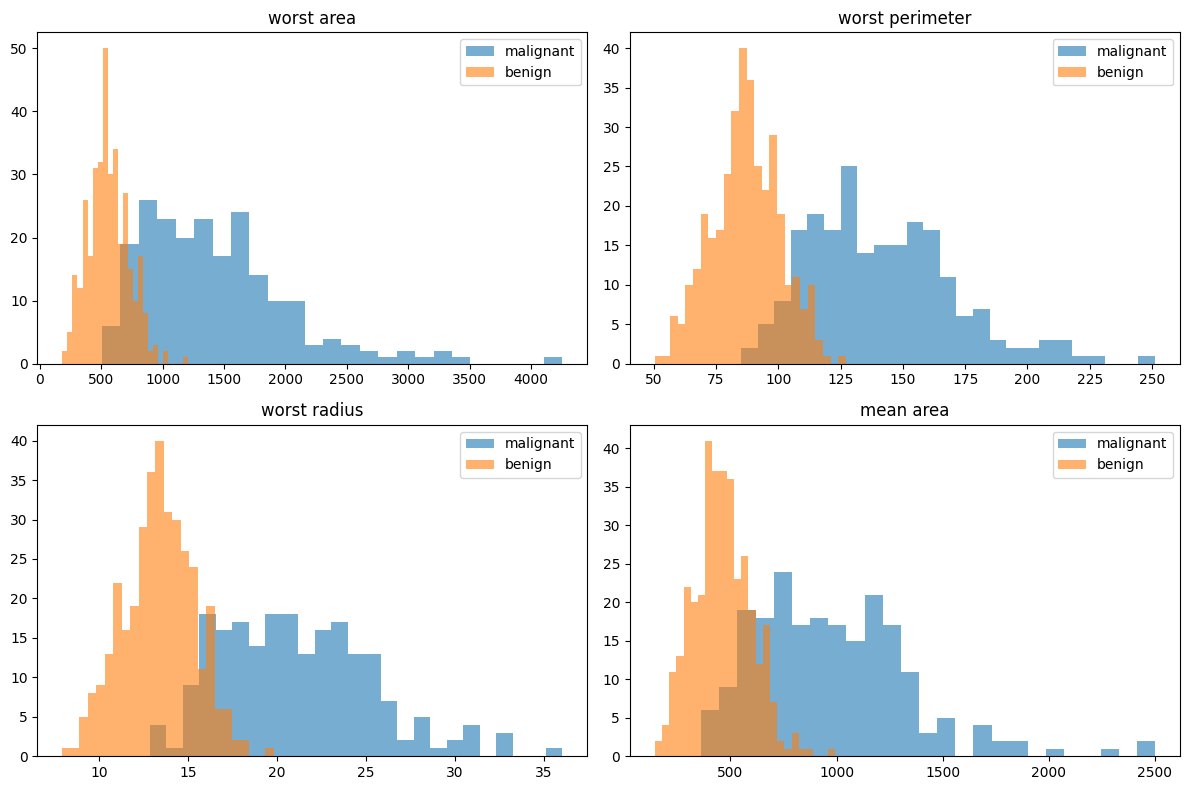

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, feature in zip(axes, top_features):
    ax.hist(df.loc[df['target'] == 0, feature], bins=25, alpha=0.6, label='malignant')
    ax.hist(df.loc[df['target'] == 1, feature], bins=25, alpha=0.6, label='benign')
    ax.set_title(feature)
    ax.legend()

plt.tight_layout()
plt.show()

## 7. Selección de 2 features para el plano 2D

Vamos a dibujar la frontera de decisión en 2D, con lo que entrenaremos el modelo con tan solo 2 features.

Tomaremos las **2 primeras del ranking combinado**.

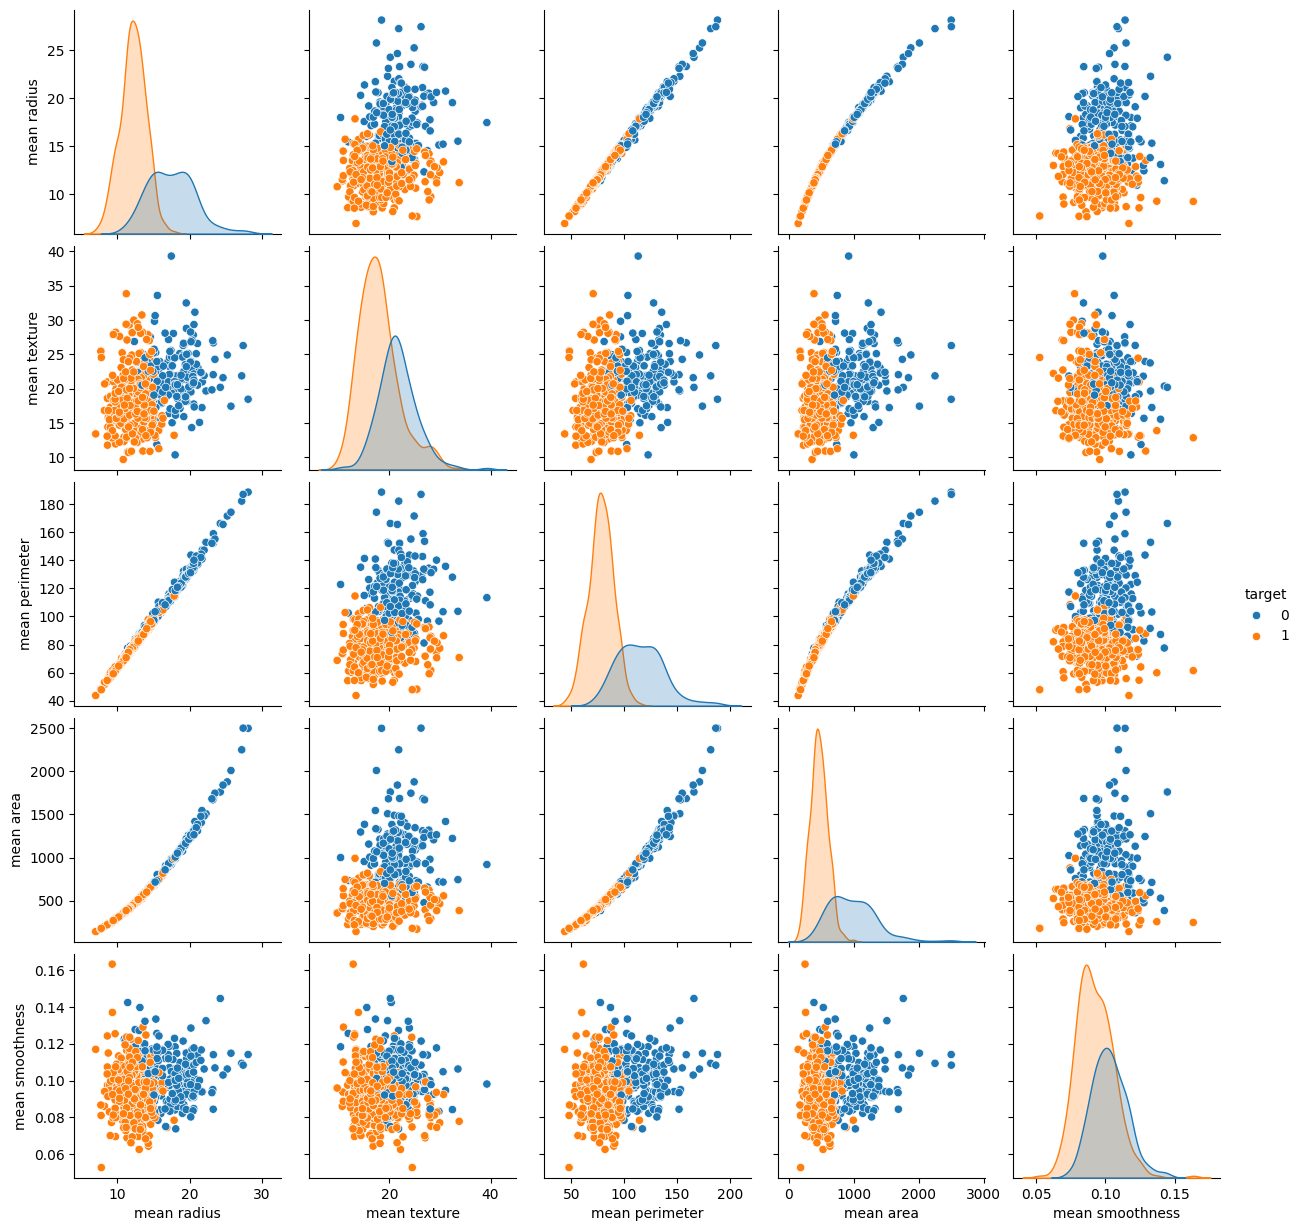

In [20]:
# pair plot of sample feature
sns.pairplot(df, hue = 'target', 
             vars = ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness'] )

In [10]:
selected_features = feature_ranking.head(2).index.tolist()
selected_features

['worst area', 'worst perimeter']

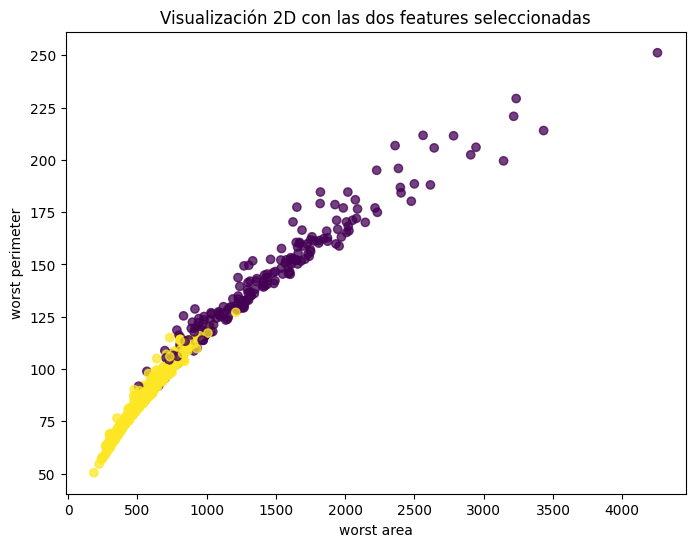

In [11]:
X_2d = df[selected_features].values

plt.figure(figsize=(8, 6))
plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=y,
    alpha=0.75
)
plt.xlabel(selected_features[0])
plt.ylabel(selected_features[1])
plt.title('Visualización 2D con las dos features seleccionadas')
plt.show()

## 8. Train / test split y escalado

En SVM (en general, en métodos basados en distancia), especialmente con kernels como `rbf`, el **escalado** es importante.

Por eso:
- separamos train/test
- ajustamos el `StandardScaler` **solo con train**
- transformamos train y test con ese mismo escalador

El ajuste del scaler con train se realiza para evitar fuga de datos (el modelo usaría info estadística del training set al evaluar en el test set)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_2d, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('X_train:', X_train_scaled.shape)
print('X_test:', X_test_scaled.shape)

X_train: (455, 2)
X_test: (114, 2)


## 9. Entrenamiento con varios kernels

Vamos a comparar:

- `linear`
- `poly`
- `rbf`
- `sigmoid`

Todos usan las mismas dos features.

In [13]:
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
results = []
models = {}

for kernel in kernels:
    model = SVC(kernel=kernel, C=1.0, gamma='scale')
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    
    results.append({'kernel': kernel, 'accuracy': acc})
    models[kernel] = model

results_df = pd.DataFrame(results).sort_values('accuracy', ascending=False)
results_df

,kernel,accuracy
0,linear,0.912281
2,rbf,0.912281
1,poly,0.894737
3,sigmoid,0.877193


## 10. Evaluación más detallada

Mejor kernel: linear
Accuracy: 0.9122807017543859


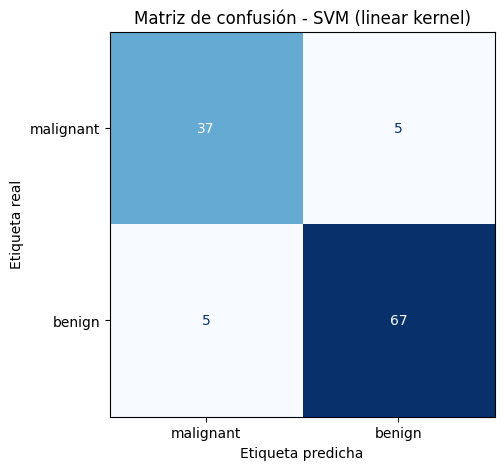


Informe de clasificación:

              precision    recall  f1-score   support

   malignant       0.88      0.88      0.88        42
      benign       0.93      0.93      0.93        72

    accuracy                           0.91       114
   macro avg       0.91      0.91      0.91       114
weighted avg       0.91      0.91      0.91       114



In [24]:
best_kernel = results_df.iloc[0]['kernel']
best_model = models[best_kernel]
best_preds = best_model.predict(X_test_scaled)

print('Mejor kernel:', best_kernel)
print('Accuracy:', accuracy_score(y_test, best_preds))

# Matriz de confusión
cm = confusion_matrix(y_test, best_preds)

fig, ax = plt.subplots(figsize=(6,5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=cancer.target_names
)

disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)

plt.title(f"Matriz de confusión - SVM ({best_kernel} kernel)")
plt.xlabel("Etiqueta predicha")
plt.ylabel("Etiqueta real")

plt.show()

print("\nInforme de clasificación:\n")
print(classification_report(y_test, best_preds, target_names=cancer.target_names))

## 11. Función para dibujar la frontera de decisión

In [15]:
def plot_decision_boundary(model, X, y, title, xlabel, ylabel):
    plt.figure(figsize=(8, 6))
    plt.scatter(X[:, 0], X[:, 1], c=y, alpha=0.8)

    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    xx, yy = np.meshgrid(
        np.linspace(xlim[0], xlim[1], 300),
        np.linspace(ylim[0], ylim[1], 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.decision_function(grid).reshape(xx.shape)

    plt.contour(
        xx, yy, Z,
        levels=[-1, 0, 1],
        alpha=0.7,
        linestyles=['--', '-', '--']
    )

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.show()

## 12. Fronteras de decisión para cada kernel

Usaremos los datos de test ya escalados para ver cómo separa cada SVM.

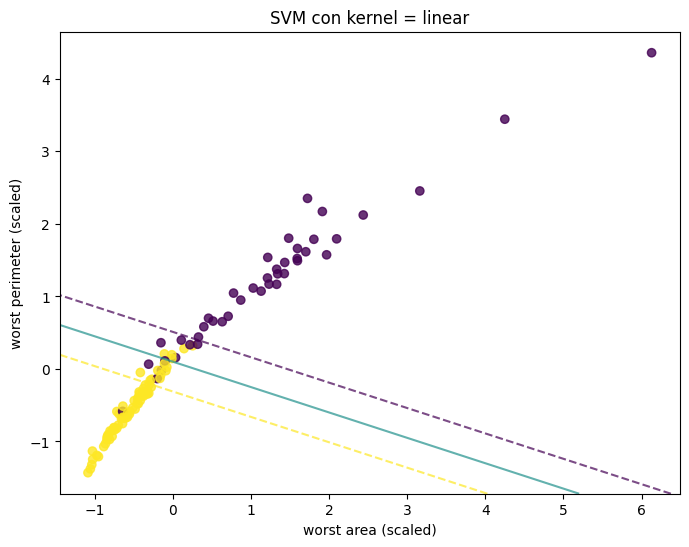

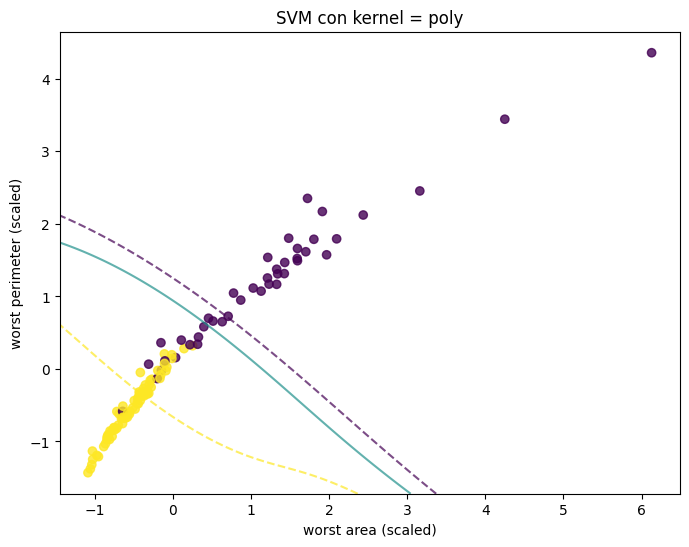

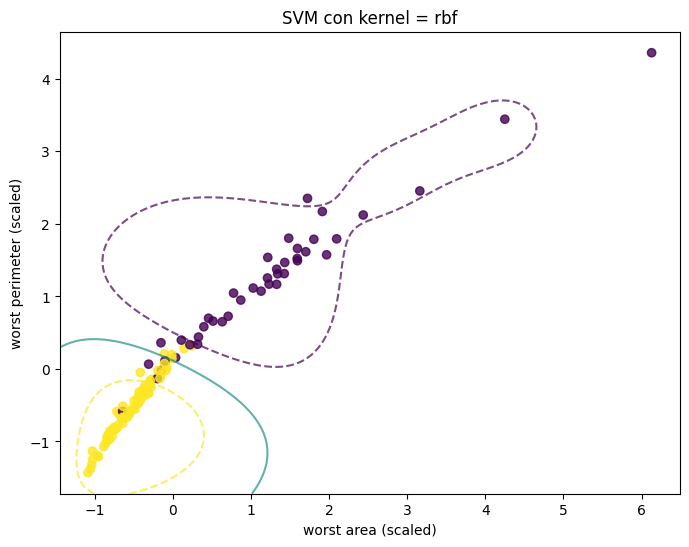

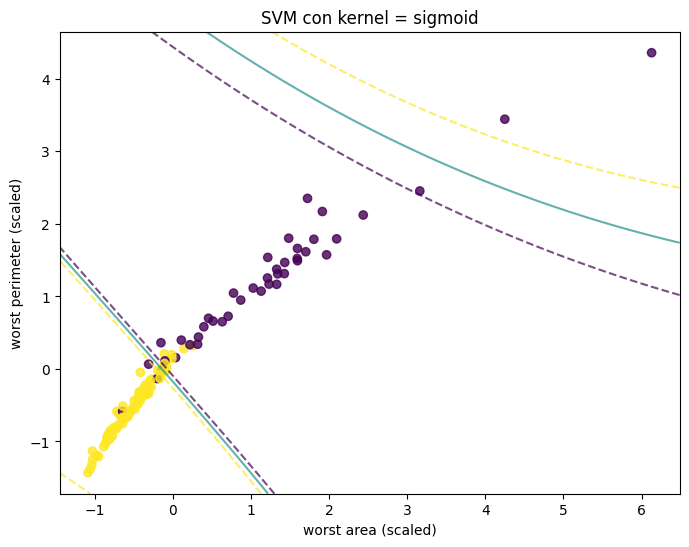

In [16]:
for kernel in kernels:
    plot_decision_boundary(
        models[kernel],
        X_test_scaled,
        y_test,
        title=f'SVM con kernel = {kernel}',
        xlabel=selected_features[0] + ' (scaled)',
        ylabel=selected_features[1] + ' (scaled)'
    )